In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar

In [2]:
np.random.seed(42)

dates = pd.date_range(start="2023-01-01", end="2023-12-31", freq="D")

products = ["Laptop", "Phone", "Tablet", "Headphones", "Monitor"]
categories = {
    "Laptop": "Electronics",
    "Phone": "Electronics",
    "Tablet": "Electronics",
    "Headphones": "Accessories",
    "Monitor": "Electronics"
}
cities = ["Kyiv", "Lviv", "Odessa", "Dnipro", "Kharkiv"]

data = []

for _ in range(1000):
    product = np.random.choice(products)
    price = np.random.randint(50, 2000)
    quantity = np.random.randint(1, 5)

    data.append([
        np.random.choice(dates),
        product,
        categories[product],
        price,
        quantity,
        np.random.choice(cities)
    ])

df = pd.DataFrame(data, columns=["Date", "Product", "Category", "Price", "Quantity", "City"])
df.to_csv("sales_data.csv", index=False)

df.head()

,Date,Product,Category,Price,Quantity,City
0,2023-04-17,Headphones,Accessories,910,3,Kharkiv
1,2023-08-03,Monitor,Electronics,1688,2,Odessa
2,2023-04-10,Tablet,Electronics,137,1,Odessa
3,2023-10-21,Monitor,Electronics,819,4,Lviv
4,2023-11-10,Headphones,Accessories,326,1,Kharkiv


In [3]:
df = pd.read_csv("sales_data.csv")
df.head()

,Date,Product,Category,Price,Quantity,City
0,2023-04-17,Headphones,Accessories,910,3,Kharkiv
1,2023-08-03,Monitor,Electronics,1688,2,Odessa
2,2023-04-10,Tablet,Electronics,137,1,Odessa
3,2023-10-21,Monitor,Electronics,819,4,Lviv
4,2023-11-10,Headphones,Accessories,326,1,Kharkiv


In [4]:
df.shape

(1000, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      1000 non-null   object
 1   Product   1000 non-null   object
 2   Category  1000 non-null   object
 3   Price     1000 non-null   int64 
 4   Quantity  1000 non-null   int64 
 5   City      1000 non-null   object
dtypes: int64(2), object(4)
memory usage: 47.0+ KB


In [6]:
df.describe()

,Price,Quantity
count,1000.00000,1000.000000
mean,1033.56200,2.485000
std,567.20722,1.132722
min,51.00000,1.000000
25%,547.50000,1.000000
50%,1003.00000,3.000000
75%,1531.50000,3.000000
max,1999.00000,4.000000


In [7]:
df.isnull().sum()

Date        0
Product     0
Category    0
Price       0
Quantity    0
City        0
dtype: int64

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df["Revenue"] = df["Price"] * df["Quantity"]

In [10]:
total_revenue = df["Revenue"].sum()
print("Total revenue:", total_revenue)

Total revenue: 2563273


In [11]:
avg_check = df["Revenue"].mean()
print("Average check:", round(avg_check, 2))

Average check: 2563.27


In [12]:
max_sale = df["Revenue"].max()
print("Max sale:", max_sale)

Max sale: 7952


In [13]:
top_products = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
top_products

Product
Monitor       543205
Laptop        533315
Tablet        527663
Headphones    480345
Phone         478745
Name: Revenue, dtype: int64

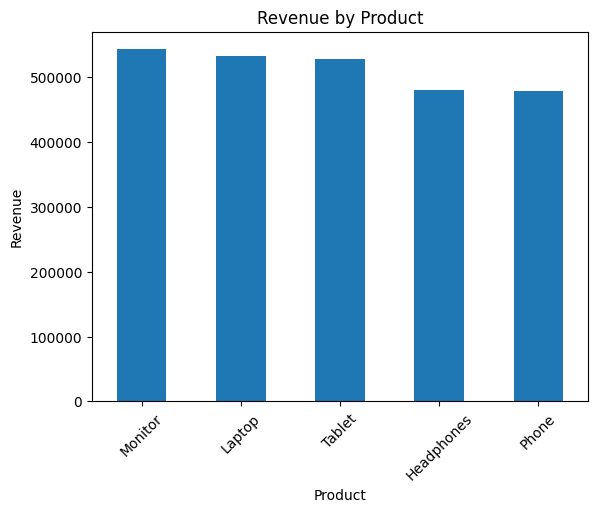

In [14]:
top_products.plot(kind="bar", title="Revenue by Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

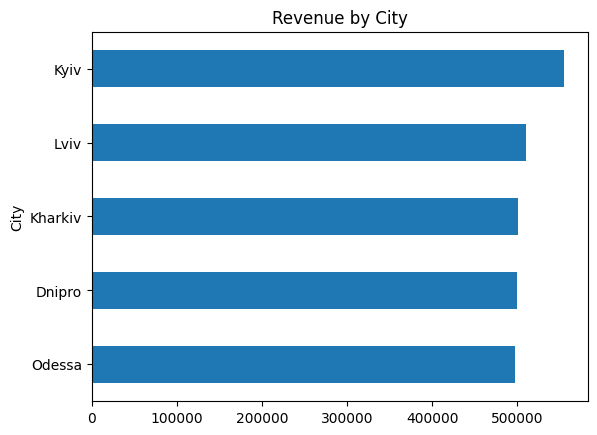

In [15]:
city_sales = df.groupby("City")["Revenue"].sum().sort_values()

city_sales.plot(kind="barh", title="Revenue by City")
plt.show()

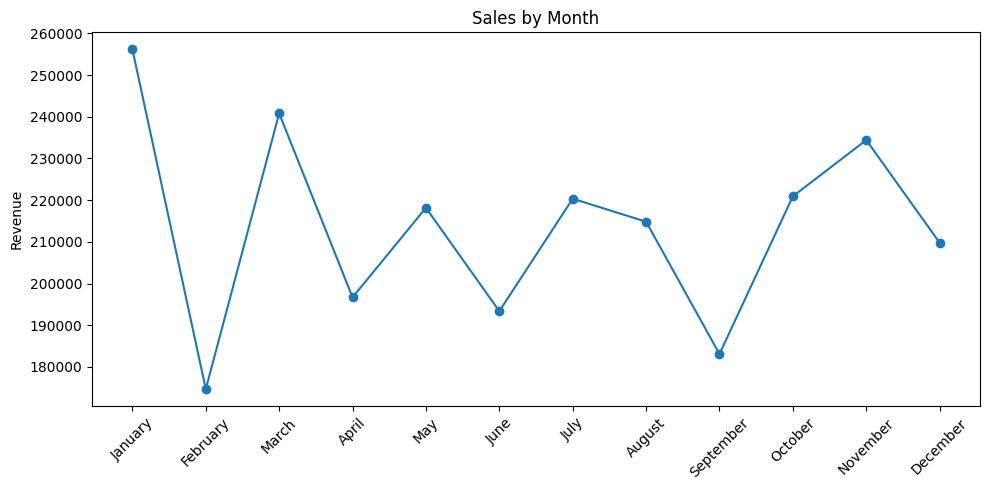

In [18]:
df["Month"] = df["Date"].dt.month

monthly_sales = df.groupby("Month")["Revenue"].sum()

monthly_sales.index = [calendar.month_name[m] for m in monthly_sales.index]

plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="line", marker="o", title="Sales by Month")

plt.ylabel("Revenue")
plt.xticks(
    ticks=range(len(monthly_sales)),
    labels=monthly_sales.index,
    rotation=45
)

plt.tight_layout()
plt.show()